# Day 7: Session 7A - The Anatomy of a Figure

[Session Webpage](https://eds-217-essential-python.github.io/course-materials/interactive-sessions/7a_matplotlib.html)

Date: 09/09/2026

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

url = 'https://eds-217-essential-python.github.io/data/toolik_weather.csv'
toolik = pd.read_csv(url)

toolik['date'] = pd.to_datetime(toolik['Date'], format='%Y%m%d')
toolik['year'] = toolik['date'].dt.year
toolik['month'] = toolik['date'].dt.month

toolik.shape

(11171, 24)

### name the two objects every matplotlib picture is made of, the figure and the axes


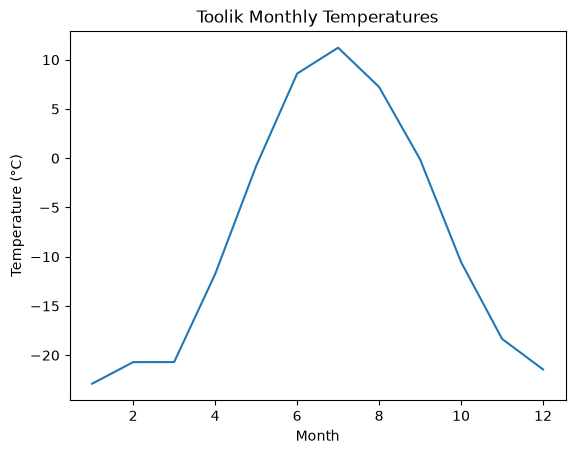

In [3]:
monthly_means = toolik.groupby('month')['Daily_AirTemp_Mean_C'].mean()

plt.plot(monthly_means)
plt.title('Toolik Monthly Temperatures')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.show()

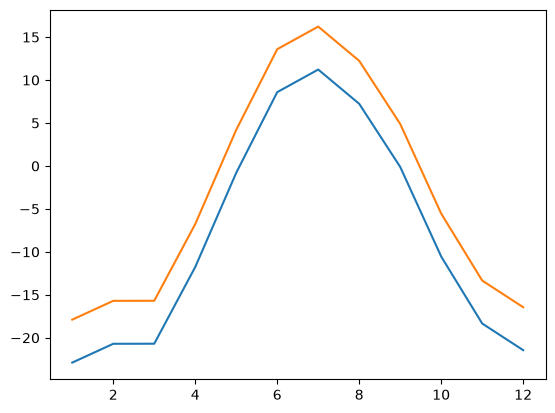

In [4]:
plt.plot(monthly_means)
plt.plot(monthly_means + 5)
plt.show()
# plots overlaid on each other 

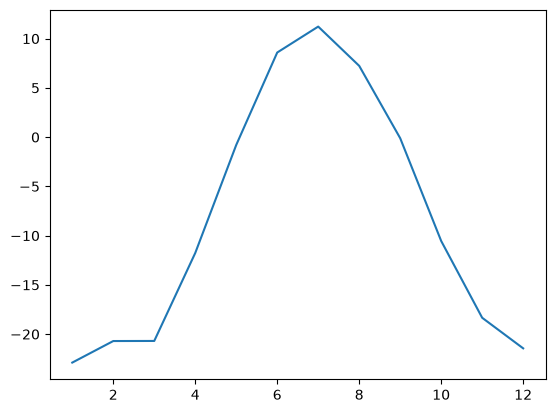

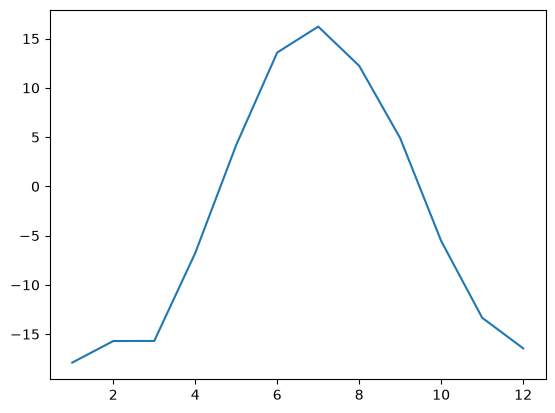

In [5]:
plt.plot(monthly_means)
plt.show()

plt.plot(monthly_means + 5)
plt.show()
# plots plotted seperately

### control the size and shape of a figure with plt.figure(figsize=)

In [6]:
# plt.figure(figsize=(width, height))
# #                    ↑       ↑
# #                  inches  inches

In [7]:
# plt.ticks(rotation=#, ha='direction')
# #           ↑               ↑
# #     degree rotation   horizontal alignment

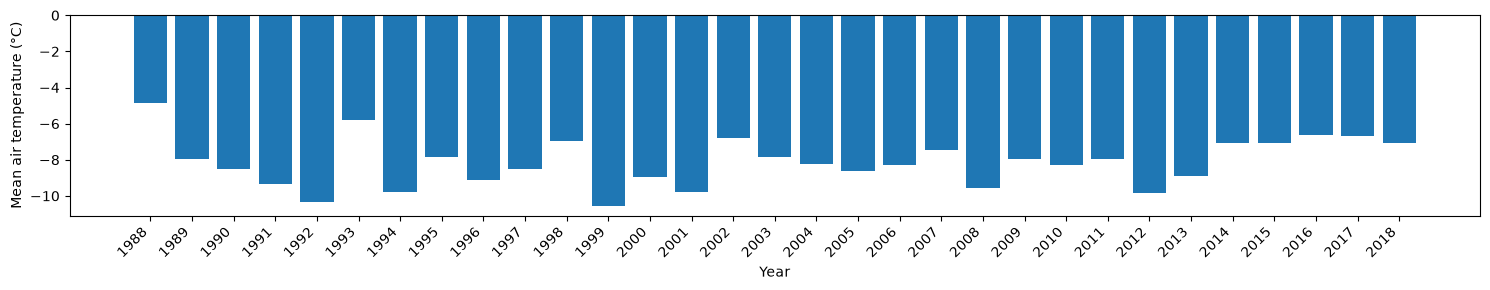

In [8]:
annual_means = toolik.groupby('year')['Daily_AirTemp_Mean_C'].mean()

# plt.figure takes a figsize= argument, a tuple of (width, height) in inches, 
# and it must come before the plotting command it applies to
plt.figure(figsize= (15, 3)) # 15 inch wide, 3 inch tall

# plt.ticks rotates every tick label on the x-axis
# and anchors its horizontal alignment
plt.xticks(rotation=45, ha='right')


plt.bar(annual_means.index.astype(str), annual_means)
plt.xlabel('Year')
plt.ylabel('Mean air temperature (°C)')

# tight_layout() measures whatever you actually plotted 
# and resizes the axes so that all of it fits
plt.tight_layout()
# matplotlib will crop elements unless tight_layout() is applied

plt.show()

### label a figure so that someone can understand what it depicts


In [9]:
# plt.xlabel('what is along the bottom, with units')
# plt.ylabel('what is up the side, with units')
# plt.title('what this figure is of')

### put two series on one set of axes and tell them apart with a legend


In [10]:
# plt.plot(x, y, label='what this line is')   # once per series
# plt.legend()                                # once per figure

In [11]:
early = toolik[toolik['year'] <= 1998]
late = toolik[toolik['year'] >= 2009]

comparison = pd.DataFrame({
    'early': early.groupby('month')['Daily_AirTemp_Mean_C'].mean(),
    'late': late.groupby('month')['Daily_AirTemp_Mean_C'].mean(),
})

comparison['change'] = comparison['late'] - comparison['early']

comparison.round(2)

,early,late,change
month,,,
1,-24.72,-21.26,3.46
2,-21.86,-19.38,2.48
3,-18.62,-20.64,-2.02
4,-10.40,-11.86,-1.45
5,0.37,-0.54,-0.91
6,8.43,8.19,-0.24
7,12.05,11.28,-0.77
8,7.48,7.18,-0.30
9,-0.85,-0.01,0.84


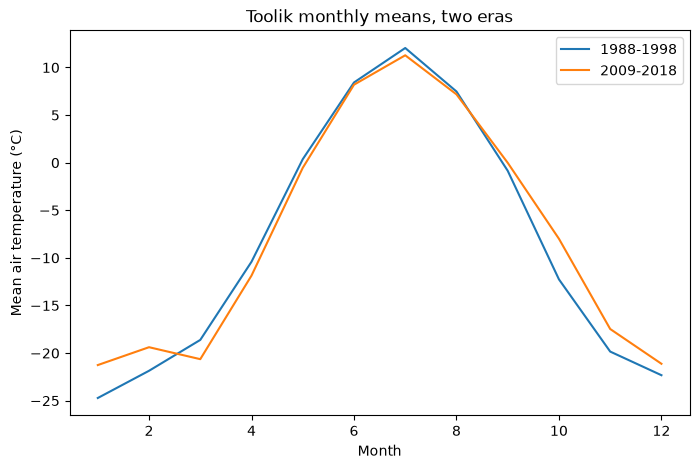

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(comparison.index, comparison['early'], label='1988-1998') # label= feeds legend !
plt.plot(comparison.index, comparison['late'], label='2009-2018')

plt.xlabel('Month')
plt.ylabel('Mean air temperature (°C)')
plt.title('Toolik monthly means, two eras')
plt.legend() # calls and visuallizes labels
plt.show()

### scatter plots

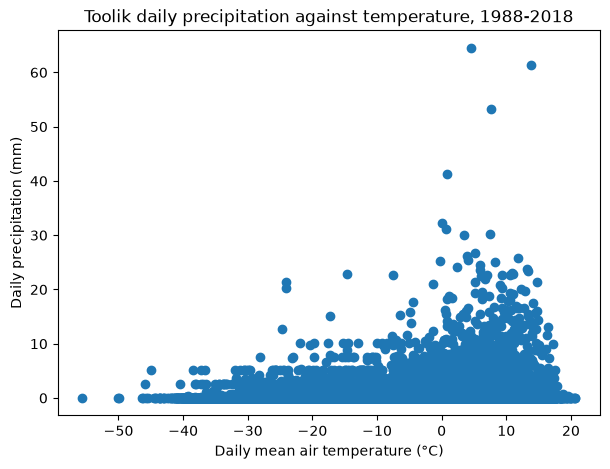

In [13]:
wet_days = toolik.dropna(subset=['Daily_Precip_Total_mm'])

plt.figure(figsize=(7, 5))

plt.scatter(wet_days['Daily_AirTemp_Mean_C'], wet_days['Daily_Precip_Total_mm'])

plt.xlabel('Daily mean air temperature (°C)')
plt.ylabel('Daily precipitation (mm)')
plt.title('Toolik daily precipitation against temperature, 1988-2018')
plt.show()

In [ ]:
# plt.scatter() takes x and y in the same order 
# plt.plot() does, and everything you have learned this session works on it unchanged: 
# figsize, labels, title, legend, rotation, tight_layout.